# Diffusion Model

References:
1. [`pts/model/time_grad/time_grad_network.py`](https://github.com/zalandoresearch/pytorch-ts/blob/master/pts/model/time_grad/time_grad_network.py)

In [2]:
import dataclasses
from functools import cached_property

import numpy as np
import pandas as pd
import plotly.express as px
import torch
import torch.nn as nn
from loguru import logger

In [3]:
@dataclasses.dataclass
class DiffusionPocessParams:
    """Parameter that defines a diffusion process.

    :param steps: Number of steps in the diffusion process.
    :param beta: Beta parameter for the diffusion process.
    """

    steps: int
    beta: float

    @cached_property
    def alpha(self) -> float:
        r"""$\alpha = 1 - \beta$"""
        return 1.0 - self.beta

    @cached_property
    def beta_by_step(self) -> np.ndarray:
        """the beta parameter for each step
        in the diffusion process.
        """
        return np.array([self.beta] * self.steps)

    @cached_property
    def alpha_by_step(self) -> np.ndarray:
        """the alpha parameter for each step
        in the diffusion process."""
        return np.array([self.alpha] * self.steps)


class DiffusionProcess:
    """
    Diffusion process.

    :param params: DiffusionParams that defines
        how the diffusion process works
    :param noise: noise tensor,
        shape is (batch_size, params.steps)
    """

    def __init__(
        self,
        params: DiffusionPocessParams,
        noise: torch.Tensor,
        dtype: torch.dtype = torch.float32,
    ):
        self.params = params
        self.noise = noise
        self.dtype = dtype

    @cached_property
    def alpha_by_step(self) -> torch.Tensor:
        """The alpha parameter for each step
        in the diffusion process.
        """
        return torch.tensor(self.params.alpha_by_step, dtype=self.dtype)

    def _forward_process_by_step(self, state: torch.Tensor, step: int) -> torch.Tensor:
        r"""Assuming that we know
        the noise at step $t$,

        $$
        x(t) = \sqrt{\alpha(t)}x(t-1)
        + \sqrt{1 - \alpha(t)}\epsilon(t)
        $$

        :param state: The state at step $t-1$.
        :param step: The current step $t$.
        :return: The state at step $t$.
        """
        return (
            torch.sqrt(self.alpha_by_step[step]) * state
            + torch.sqrt(1 - self.alpha_by_step[step]) * self.noise[:, step]
        )

    def _inverse_process_by_step(self, state: torch.Tensor, step: int) -> torch.Tensor:
        r"""Assuming that we know
        the noise at step $t$,

        $$
        x(t-1) = \frac{1}{\sqrt{\alpha(t)}}
        (x(t) - \sqrt{1 - \alpha(t)}\epsilon(t))
        $$
        """
        return (
            state - torch.sqrt(1 - self.alpha_by_step[step]) * self.noise[:, step]
        ) / torch.sqrt(self.alpha_by_step[step])


def gaussian_noise(n_var: int, length: int) -> torch.Tensor:
    """Generate a Gaussian noise tensor.

    :param n_var: Number of variables.
    :param length: Length of the tensor.
    """
    return torch.normal(mean=0, std=1, size=(n_var, length))

In [4]:
diffusion_process_params = DiffusionPocessParams(
    steps=100,
    beta=0.005,
    # beta=0,
)
diffusion_batch_size = 1000
# diffusion_batch_size = 2

noise = gaussian_noise(diffusion_batch_size, diffusion_process_params.steps)

diffusion_process = DiffusionProcess(diffusion_process_params, noise=noise)

In [5]:
# diffusion_initial_x = torch.sin(
#     torch.linspace(0, 1, diffusion_batch_size)
#     .reshape(diffusion_batch_size)
# )

diffusion_initial_x = torch.rand(diffusion_batch_size)
# diffusion_initial_x = (
#     torch.distributions.Beta(torch.tensor([0.5]), torch.tensor([0.5]))
#     .sample((diffusion_batch_size, 1))
#     .reshape(diffusion_batch_size)
# )

diffusion_initial_x

tensor([0.7536, 0.4834, 0.2725, 0.4402, 0.3182, 0.6672, 0.1673, 0.5404, 0.4067,
        0.7054, 0.8827, 0.8709, 0.7129, 0.1326, 0.8437, 0.0955, 0.4977, 0.3243,
        0.8288, 0.8126, 0.0969, 0.1552, 0.0496, 0.9418, 0.8736, 0.3177, 0.8175,
        0.1994, 0.9418, 0.2020, 0.5799, 0.2483, 0.2041, 0.6654, 0.1592, 0.3804,
        0.5947, 0.6441, 0.6036, 0.3260, 0.9430, 0.9195, 0.8601, 0.8360, 0.2365,
        0.9118, 0.9763, 0.4900, 0.0756, 0.9563, 0.6160, 0.8516, 0.3618, 0.9157,
        0.2769, 0.4257, 0.8229, 0.5218, 0.8965, 0.8164, 0.5145, 0.6978, 0.6188,
        0.4195, 0.0356, 0.0889, 0.8554, 0.9192, 0.5285, 0.8589, 0.1101, 0.5923,
        0.1385, 0.3004, 0.8923, 0.0815, 0.2056, 0.8347, 0.3738, 0.5608, 0.1239,
        0.6954, 0.5872, 0.5123, 0.3754, 0.8145, 0.8538, 0.0713, 0.5971, 0.5287,
        0.0624, 0.6684, 0.3870, 0.0232, 0.9381, 0.8042, 0.0024, 0.3759, 0.9874,
        0.6877, 0.4573, 0.4705, 0.7036, 0.1097, 0.9186, 0.1192, 0.6941, 0.1958,
        0.2448, 0.8155, 0.1737, 0.3155, 

## Forward process step by step

In [6]:
diffusion_steps_step_by_step = [diffusion_initial_x.detach().numpy()]

for i in range(0, diffusion_process_params.steps):
    logger.info(f"step {i}")
    i_state = (
        diffusion_process._forward_process_by_step(
            torch.from_numpy(diffusion_steps_step_by_step[-1]), step=i
        )
        .detach()
        .numpy()
    )
    logger.info(f"i_state {i_state[:2]}")
    diffusion_steps_step_by_step.append(i_state)


2025-05-23 23:28:27.234 | INFO     | __main__:<module>:4 - step 0
2025-05-23 23:28:27.245 | INFO     | __main__:<module>:12 - i_state [0.7522126 0.5337955]
2025-05-23 23:28:27.246 | INFO     | __main__:<module>:4 - step 1
2025-05-23 23:28:27.247 | INFO     | __main__:<module>:12 - i_state [0.759702  0.4074335]
2025-05-23 23:28:27.247 | INFO     | __main__:<module>:4 - step 2
2025-05-23 23:28:27.248 | INFO     | __main__:<module>:12 - i_state [0.76101214 0.32328355]
2025-05-23 23:28:27.248 | INFO     | __main__:<module>:4 - step 3
2025-05-23 23:28:27.249 | INFO     | __main__:<module>:12 - i_state [0.68993694 0.30957484]
2025-05-23 23:28:27.250 | INFO     | __main__:<module>:4 - step 4
2025-05-23 23:28:27.250 | INFO     | __main__:<module>:12 - i_state [0.64033353 0.21329316]
2025-05-23 23:28:27.250 | INFO     | __main__:<module>:4 - step 5
2025-05-23 23:28:27.251 | INFO     | __main__:<module>:12 - i_state [0.6169239  0.11197086]
2025-05-23 23:28:27.251 | INFO     | __main__:<module>:4

In [7]:
px.histogram(diffusion_initial_x)

In [8]:
px.histogram(diffusion_steps_step_by_step[0])

In [9]:
px.histogram(diffusion_steps_step_by_step[-1])

## Reverse step by step

In [10]:
diffusion_steps_reverse = [diffusion_steps_step_by_step[-1]]

for i in range(diffusion_process_params.steps - 1, -1, -1):
    logger.info(f"step {i}")
    i_state = (
        diffusion_process._inverse_process_by_step(
            torch.from_numpy(diffusion_steps_reverse[-1]), step=i
        )
        .detach()
        .numpy()
    )
    logger.info(f"i_state {i_state[:2]}")
    diffusion_steps_reverse.append(i_state)


2025-05-23 23:28:27.765 | INFO     | __main__:<module>:4 - step 99
2025-05-23 23:28:27.767 | INFO     | __main__:<module>:12 - i_state [0.7941074  0.46556577]
2025-05-23 23:28:27.767 | INFO     | __main__:<module>:4 - step 98
2025-05-23 23:28:27.768 | INFO     | __main__:<module>:12 - i_state [0.7774506  0.35429615]
2025-05-23 23:28:27.769 | INFO     | __main__:<module>:4 - step 97
2025-05-23 23:28:27.770 | INFO     | __main__:<module>:12 - i_state [0.7224949  0.30691206]
2025-05-23 23:28:27.770 | INFO     | __main__:<module>:4 - step 96
2025-05-23 23:28:27.771 | INFO     | __main__:<module>:12 - i_state [0.61677593 0.19635741]
2025-05-23 23:28:27.771 | INFO     | __main__:<module>:4 - step 95
2025-05-23 23:28:27.772 | INFO     | __main__:<module>:12 - i_state [0.5260309  0.23809095]
2025-05-23 23:28:27.772 | INFO     | __main__:<module>:4 - step 94
2025-05-23 23:28:27.773 | INFO     | __main__:<module>:12 - i_state [0.50137323 0.22013015]
2025-05-23 23:28:27.774 | INFO     | __main__:

In [11]:
px.histogram(diffusion_steps_reverse[0])

In [12]:
px.histogram(diffusion_steps_reverse[-1])

## Diffusion Distributions

In [13]:
df_diffusion_example = pd.DataFrame(
    {i: v for i, v in enumerate(diffusion_steps_step_by_step)}
).T
df_diffusion_example["step"] = df_diffusion_example.index

df_diffusion_example_melted = df_diffusion_example.melt(
    id_vars=["step"], var_name="variable", value_name="value"
)
df_diffusion_example_melted.tail()

,step,variable,value
100995,96,999,-0.522642
100996,97,999,-0.535914
100997,98,999,-0.525615
100998,99,999,-0.621378
100999,100,999,-0.549157


In [14]:
px.histogram(
    df_diffusion_example_melted,
    x="value",
    histnorm="probability density",
    animation_frame="step",
)

/Users/leima/git/github/emptymalei/deep-learning/.venv/lib/python3.10/site-packages/plotly/express/_core.py:1985: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



In [15]:
px.violin(
    df_diffusion_example_melted.loc[
        df_diffusion_example_melted["step"].isin(
            [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
        )
    ],
    x="step",
    y="value",
)

In [16]:
px.line(
    df_diffusion_example_melted,
    x="step",
    y="value",
    color="variable",
)

/Users/leima/git/github/emptymalei/deep-learning/.venv/lib/python3.10/site-packages/plotly/express/_core.py:1985: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



## Create Visuals

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 0, 'Position')

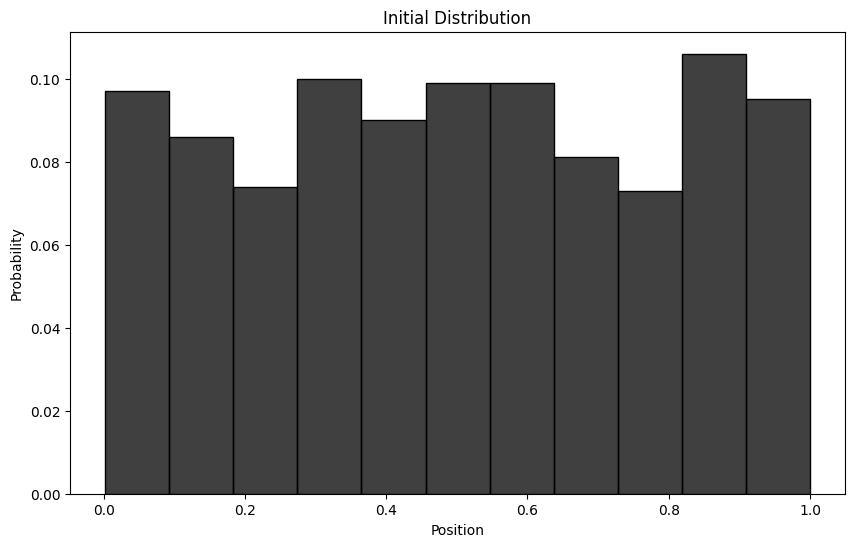

In [18]:
_, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    df_diffusion_example_melted.loc[df_diffusion_example_melted["step"] == 0],
    x="value",
    stat="probability",
    color="k",
    label="Initial Distribution",
    ax=ax,
)

ax.set_title("Initial Distribution")
ax.set_xlabel("Position")

Text(0.5, 0, 'Position')

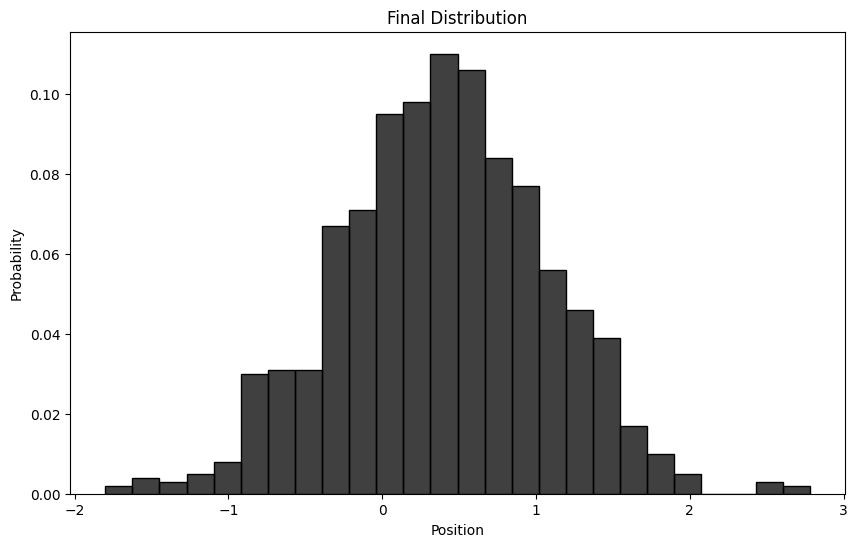

In [19]:
_, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    df_diffusion_example_melted.loc[
        df_diffusion_example_melted["step"] == max(df_diffusion_example_melted["step"])
    ],
    x="value",
    stat="probability",
    color="k",
    ax=ax,
)

ax.set_title("Final Distribution")
ax.set_xlabel("Position")

In [20]:
df_diffusion_example_melted

,step,variable,value
0,0,0,0.753597
1,1,0,0.752213
2,2,0,0.759702
3,3,0,0.761012
4,4,0,0.689937
...,...,...,...
100995,96,999,-0.522642
100996,97,999,-0.535914
100997,98,999,-0.525615
100998,99,999,-0.621378


Text(0, 0.5, 'Particle Position')

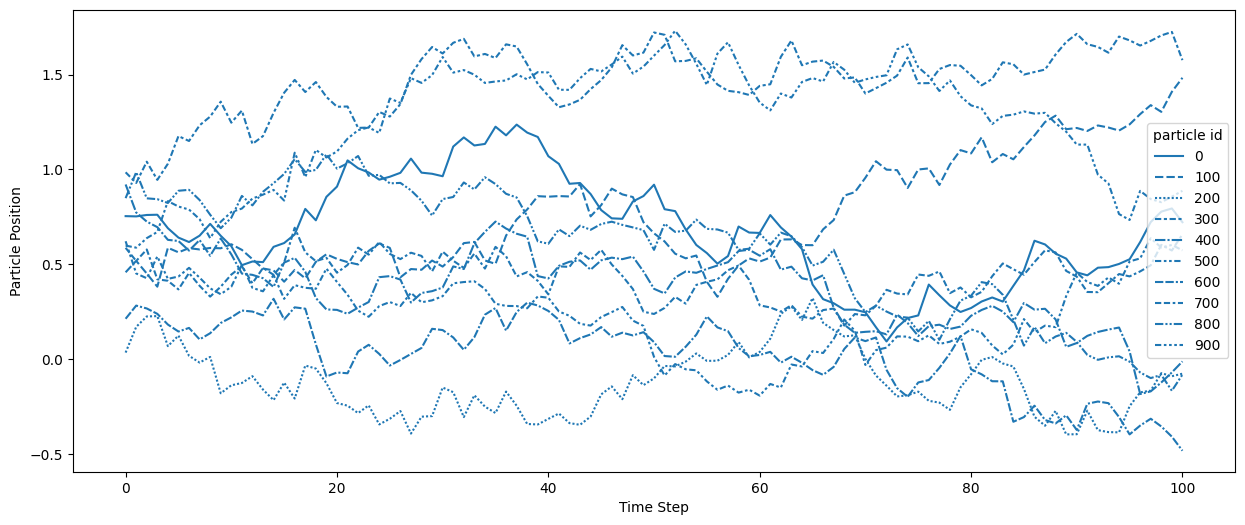

In [21]:
_, ax = plt.subplots(figsize=(15, 6))

sns.lineplot(
    df_diffusion_example_melted.loc[
        df_diffusion_example_melted["variable"].isin(
            [0, 100, 200, 300, 400, 500, 600, 700, 800, 900]
        )
    ].rename(columns={"variable": "particle id"}),
    x="step",
    y="value",
    style="particle id",
)

ax.set_xlabel("Time Step")
ax.set_ylabel("Particle Position")

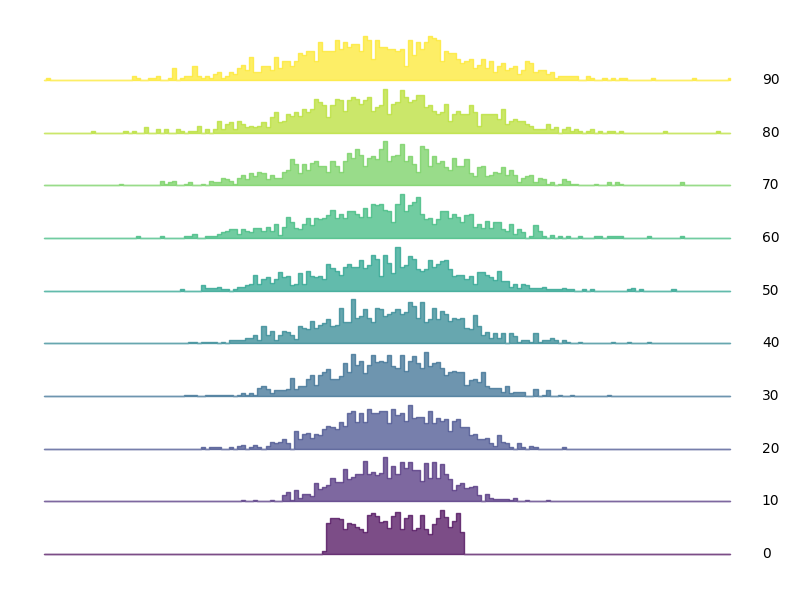

In [22]:
ridge_steps = 10


fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0, 1, ridge_steps))
bin_edges = np.histogram_bin_edges(df_diffusion_example_melted["value"], bins="auto")

for i, step in enumerate([0, 10, 20, 30, 40, 50, 60, 70, 80, 90]):
    values = df_diffusion_example_melted[df_diffusion_example_melted["step"] == step][
        "value"
    ]
    counts, _ = np.histogram(values, bins=bin_edges)
    counts = counts / counts.max()

    offset = i * 1.2
    ax.fill_between(
        bin_edges[:-1], offset, counts + offset, step="mid", color=colors[i], alpha=0.7
    )
    ax.text(bin_edges[-1] + 0.2, offset, step, va="center")


ax.axes.get_yaxis().set_visible(False)

plt.axis("off")
ax.set_xlabel("Position")
plt.tight_layout()


# Model

We create a naive model based on the idea of diffusion.

1. Connect the real data to the latent space through diffusion process.
2. We forecast in the latent space.

In [23]:
import lightning.pytorch as pl
from lightning import LightningModule

In [24]:
@dataclasses.dataclass
class LatentRNNParams:
    """Parameters for Diffusion process.

    :param latent_size: latent space dimension
    :param history_length: input sequence length
    :param n_features: number of features
    """

    history_length: int
    latent_size: int = 100
    num_layers: int = 2
    n_features: int = 1
    initial_state: torch.Tensor = None

    @cached_property
    def data_size(self) -> int:
        """The dimension of the input data
        when flattened.
        """
        return self.sequence_length * self.n_features

    def asdict(self) -> dict:
        return dataclasses.asdict(self)


class LatentRNN(nn.Module):
    """Forecasting the next step in latent space."""

    def __init__(self, params: LatentRNNParams):
        super().__init__()

        self.params = params
        self.hparams = params.asdict()

        self.rnn = nn.GRU(
            input_size=self.params.history_length,
            hidden_size=self.params.latent_size,
            num_layers=self.params.num_layers,
            batch_first=True,
        )

    def forward(
        self, x: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """

        :param x: input data, shape (batch_size, history_length * n_features)
        """

        outputs, _ = self.rnn(x, self.params.initial_state)

        return outputs


class DiffusionEncoder(nn.Module):
    """Encode the time series into the latent space."""

    def __init__(
        self,
        params: DiffusionPocessParams,
        noise: torch.Tensor,
    ):
        super().__init__()
        self.params = params
        self.noise = noise

    @staticmethod
    def _forward_process_by_step(
        state: torch.Tensor, alpha_by_step: torch.Tensor, noise: torch.Tensor, step: int
    ) -> torch.Tensor:
        r"""Assuming that we know the noise at step $t$,

        $$
        x(t) = \sqrt{\alpha(t)}x(t-1) + \sqrt{1 - \alpha(t)}\epsilon(t)
        $$
        """
        batch_size = state.shape[0]
        return torch.sqrt(alpha_by_step[step]) * state + (
            torch.sqrt(1 - alpha_by_step[step]) * noise[:batch_size, step]
        ).reshape(batch_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Encoding the latent space into a distribution.

        :param x: input data, shape (batch_size, history_length, n_features)
        """

        alpha_by_step = torch.tensor(self.params.alpha_by_step).to(x)
        self.noise = self.noise.to(x)
        # logger.debug(
        #     f"alpha_by_step: {alpha_by_step.shape}"
        #     f"noise: {self.noise.shape}"
        #     f"x: {x.shape}"
        # )

        diffusion_steps_step_by_step = [x]

        for i in range(0, self.params.steps):
            i_state = self._forward_process_by_step(
                diffusion_steps_step_by_step[-1],
                alpha_by_step=alpha_by_step,
                noise=self.noise,
                step=i,
            )
            diffusion_steps_step_by_step.append(i_state)

        return diffusion_steps_step_by_step[-1]


class DiffusionDecoder(nn.Module):
    """Decode the latent space into a distribution."""

    def __init__(
        self,
        params: DiffusionPocessParams,
        noise: torch.Tensor,
    ):
        super().__init__()
        self.params = params
        self.noise = noise

    @staticmethod
    def _inverse_process_by_step(
        state: torch.Tensor, alpha_by_step: torch.Tensor, noise: torch.Tensor, step: int
    ) -> torch.Tensor:
        r"""Assuming that we know the noise at step $t$,

        $$
        x(t-1) = \frac{1}{\sqrt{\alpha(t)}}
        (x(t) - \sqrt{1 - \alpha(t)}\epsilon(t))
        $$
        """
        batch_size = state.shape[0]
        return (
            state
            - (torch.sqrt(1 - alpha_by_step[step]) * noise[:batch_size, step]).reshape(
                batch_size, 1
            )
        ) / torch.sqrt(alpha_by_step[step])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Encoding the latent space into a distribution.

        :param x: input data, shape (batch_size, history_length, n_features)
        """
        alpha_by_step = torch.tensor(self.params.alpha_by_step).to(x)
        self.noise = self.noise.to(x)

        diffusion_steps_reverse = [x]

        for i in range(self.params.steps - 1, -1, -1):
            i_state = self._inverse_process_by_step(
                state=diffusion_steps_reverse[-1],
                alpha_by_step=alpha_by_step,
                noise=self.noise,
                step=i,
            )
            diffusion_steps_reverse.append(i_state)

        return diffusion_steps_reverse[-1]


class NaiveDiffusionModel(nn.Module):
    """A naive diffusion model that explicitly calculates
    the diffusion process.
    """

    def __init__(
        self,
        rnn: LatentRNN,
        diffusion_decoder: DiffusionDecoder,
        diffusion_encoder: DiffusionEncoder,
        horizon: int = 1,
    ):
        super().__init__()
        self.rnn = rnn
        self.diffusion_decoder = diffusion_decoder
        self.diffusion_encoder = diffusion_encoder
        self.horizon = horizon
        self.scale = nn.Linear(
            in_features=self.rnn.params.latent_size,
            out_features=self.horizon,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # logger.debug(f"x.squeeze(-1): {x.squeeze(-1).shape=}")
        x_latent = self.diffusion_encoder(x.squeeze(-1))
        # logger.debug(f"x_latent: {x_latent.shape=}")
        y_latent = self.rnn(x_latent)
        # logger.debug(f"y_latent: {y_latent.shape=}")
        y_hat = self.diffusion_decoder(y_latent)
        # logger.debug(f"y_hat: {y_hat.shape=}")
        y_hat = self.scale(y_hat)
        # logger.debug(f"scaled y_hat: {y_hat.shape=}")

        return y_hat


class NaiveDiffusionForecaster(LightningModule):
    """A assembled lightning module for the naive diffusion model."""

    def __init__(
        self,
        model: NaiveDiffusionModel,
        loss: nn.Module = nn.MSELoss(),
    ):
        super().__init__()
        self.model = model
        self.loss = loss

    def configure_optimizers(self):
        optimizer = torch.optim.SGD(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        x = x.type(self.dtype)
        y = y.type(self.dtype)
        batch_size = x.shape[0]

        y_hat = self.model(x)[:batch_size, :].reshape_as(y)

        loss = self.loss(y_hat, y).mean()
        self.log_dict({"train_loss": loss}, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        x = x.type(self.dtype)
        y = y.type(self.dtype)
        batch_size = x.shape[0]

        y_hat = self.model(x)[:batch_size, :].reshape_as(y)

        loss = self.loss(y_hat, y).mean()
        self.log_dict({"val_loss": loss}, prog_bar=True)
        return loss

    def predict_step(self, batch, batch_idx):
        x, y = batch
        x = x.type(self.dtype)
        y = y.type(self.dtype)
        batch_size = x.shape[0]

        y_hat = self.model(x)[:batch_size, :].reshape_as(y)
        return x, y_hat

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.to(self.model.rnn.rnn.weight_ih_l0)
        return self.model(x)

<Axes: xlabel='t'>

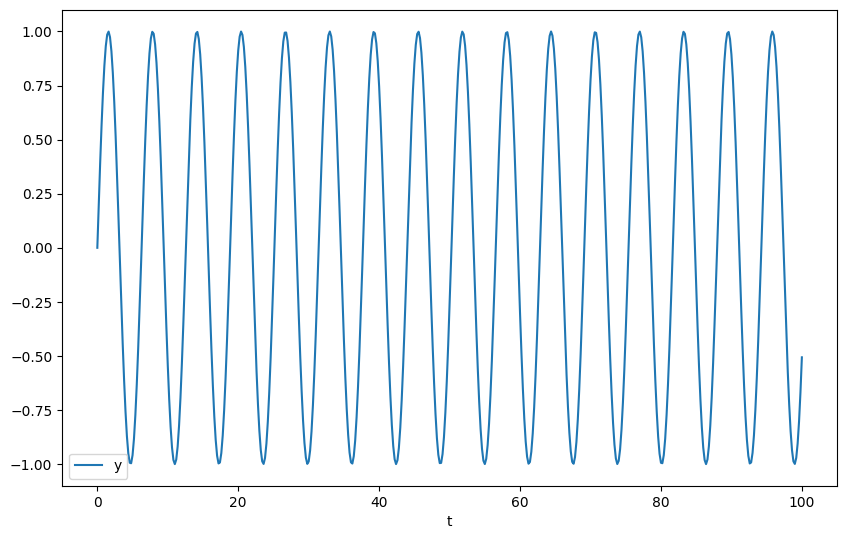

In [25]:
df = pd.DataFrame(
    {"t": np.linspace(0, 100, 501), "y": np.sin(np.linspace(0, 100, 501))}
)

_, ax = plt.subplots(figsize=(10, 6.18))

df.plot(x="t", y="y", ax=ax)

## Traning

In [26]:
from ts_bolt.datamodules.pandas import DataFrameDataModule

In [27]:
history_length_1_step = 100
horizon_1_step = 1
training_batch_size = 64

training_noise = gaussian_noise(training_batch_size, diffusion_process_params.steps)

In [28]:
diffusion_process_params.alpha_by_step.shape, training_noise.shape

((100,), torch.Size([64, 100]))

In [29]:
test_state = torch.rand(training_batch_size, diffusion_process_params.steps)
test_state.shape

torch.Size([64, 100])

In [30]:
torch.sqrt(torch.from_numpy(diffusion_process_params.alpha_by_step)[0])

tensor(0.9975, dtype=torch.float64)

In [31]:
(
    test_state
    - torch.sqrt(torch.from_numpy(diffusion_process_params.alpha_by_step)[0])
    * training_noise[:, 0].reshape(training_batch_size, 1)
).shape

torch.Size([64, 100])

In [32]:
pdm_1_step = DataFrameDataModule(
    history_length=history_length_1_step,
    horizon=horizon_1_step,
    dataframe=df[["y"]].astype(np.float32),
    batch_size=training_batch_size,
)

In [33]:
diffusion_decoder = DiffusionDecoder(diffusion_process_params, training_noise)
diffusion_encoder = DiffusionEncoder(diffusion_process_params, training_noise)

In [34]:
latent_rnn_params = LatentRNNParams(
    history_length=history_length_1_step,
    latent_size=diffusion_process_params.steps,
)

latent_rnn = LatentRNN(latent_rnn_params)

In [35]:
naive_diffusion_model = NaiveDiffusionModel(
    rnn=latent_rnn,
    diffusion_decoder=diffusion_decoder,
    diffusion_encoder=diffusion_encoder,
)
naive_diffusion_forecaster = NaiveDiffusionForecaster(
    model=naive_diffusion_model.float(),
)

In [36]:
naive_diffusion_forecaster

NaiveDiffusionForecaster(
  (model): NaiveDiffusionModel(
    (rnn): LatentRNN(
      (rnn): GRU(100, 100, num_layers=2, batch_first=True)
    )
    (diffusion_decoder): DiffusionDecoder()
    (diffusion_encoder): DiffusionEncoder()
    (scale): Linear(in_features=100, out_features=1, bias=True)
  )
  (loss): MSELoss()
)

In [37]:
logger_1_step = pl.loggers.TensorBoardLogger(
    save_dir="lightning_logs", name="naive_diffusion_ts_1_step"
)
precision = "64"
trainer_1_step = pl.Trainer(
    # precision="32",
    precision=precision,
    # max_epochs=5000,
    max_epochs=10000,
    min_epochs=5,
    # callbacks=[
    #     pl.callbacks.early_stopping.EarlyStopping(monitor="val_loss", mode="min", min_delta=1e-8, patience=4)
    # ],
    logger=logger_1_step,
    # accelerator="mps",
    accelerator="cuda",
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [ ]:
trainer_1_step.fit(model=naive_diffusion_forecaster, datamodule=pdm_1_step)


  | Name  | Type                | Params
----------------------------------------------
0 | model | NaiveDiffusionModel | 121 K 
1 | loss  | MSELoss             | 0     
----------------------------------------------
121 K     Trainable params
0         Non-trainable params
121 K     Total params
0.485     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/leima/git/github/emptymalei/deep-learning/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/leima/git/github/emptymalei/deep-learning/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/leima/git/github/emptymalei/deep-learning/.venv/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:293: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epo

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

# Evaluation

In [ ]:
from typing import Dict, List, Sequence, Tuple

import matplotlib as mpl
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from torchmetrics import MetricCollection
from torchmetrics.regression import (
    MeanAbsoluteError,
    MeanAbsolutePercentageError,
    MeanSquaredError,
    SymmetricMeanAbsolutePercentageError,
)
from ts_bolt.evaluation.evaluator import Evaluator
from ts_bolt.naive_forecasters.last_observation import LastObservationForecaster


class Evaluator:
    """Evaluate the predictions

    :param step: which prediction step to be evaluated.
    :param gap: gap between input history and target/prediction.
    """

    def __init__(self, step: int = 0, gap: int = 0):
        self.step = step
        self.gap = gap

    @staticmethod
    def get_one_history(
        predictions: Sequence[Sequence], idx: int, batch_idx: int = 0
    ) -> torch.Tensor:
        return predictions[batch_idx][0][idx, ...]

    @staticmethod
    def get_one_pred(predictions: List, idx: int, batch_idx: int = 0) -> torch.Tensor:
        return predictions[batch_idx][1][idx, ...]

    @staticmethod
    def get_y(predictions: List, step: int) -> List[torch.Tensor]:
        return [i[1][..., step] for i in predictions]

    def y(self, predictions: List, batch_idx: int = 0) -> torch.Tensor:
        return self.get_y(predictions, self.step)[batch_idx].detach()

    @staticmethod
    def get_y_true(dataloader: DataLoader, step: int) -> list[torch.Tensor]:
        return [i[1][..., step] for i in dataloader]

    def y_true(self, dataloader: DataLoader, batch_idx: int = 0) -> torch.Tensor:
        return self.get_y_true(dataloader, step=self.step)[batch_idx].detach()

    def get_one_sample(
        self, predictions: List, idx: int, batch_idx: int = 0
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        return (
            self.get_one_history(predictions, idx, batch_idx),
            self.get_one_pred(predictions, idx, batch_idx),
        )

    def plot_one_sample(
        self, ax: mpl.axes.Axes, predictions: List, idx: int, batch_idx: int = 0
    ) -> None:
        history, pred = self.get_one_sample(predictions, idx, batch_idx)

        x_raw = np.arange(len(history) + len(pred) + self.gap)
        x_history = x_raw[: len(history)]
        x_pred = x_raw[len(history) + self.gap :]
        x = np.concatenate([x_history, x_pred])

        y = np.concatenate([history, pred])

        ax.plot(x, y, marker=".", label=f"input ({idx})")

        ax.axvspan(x_pred[0], x_pred[-1], color="orange", alpha=0.1)

    @property
    def metric_collection(self) -> MetricCollection:
        return MetricCollection(
            MeanAbsoluteError(),
            MeanAbsolutePercentageError(),
            MeanSquaredError(),
            SymmetricMeanAbsolutePercentageError(),
        )

    @staticmethod
    def metric_dataframe(metrics: Dict) -> pd.DataFrame:
        return pd.DataFrame(
            [{k: float(v) for k, v in metrics.items()}], index=["values"]
        ).T

    def metrics(
        self, predictions: List, dataloader: DataLoader, batch_idx: int = 0
    ) -> pd.DataFrame:
        truths = self.y_true(dataloader)
        preds = self.y(predictions, batch_idx=batch_idx)

        return self.metric_dataframe(self.metric_collection(preds, truths))

In [ ]:
evaluator_1_step = Evaluator(step=0)

In [ ]:
predictions_1_step = trainer_1_step.predict(
    model=naive_diffusion_forecaster, datamodule=pdm_1_step
)

/Users/leima/git/github/emptymalei/deep-learning/.venv/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

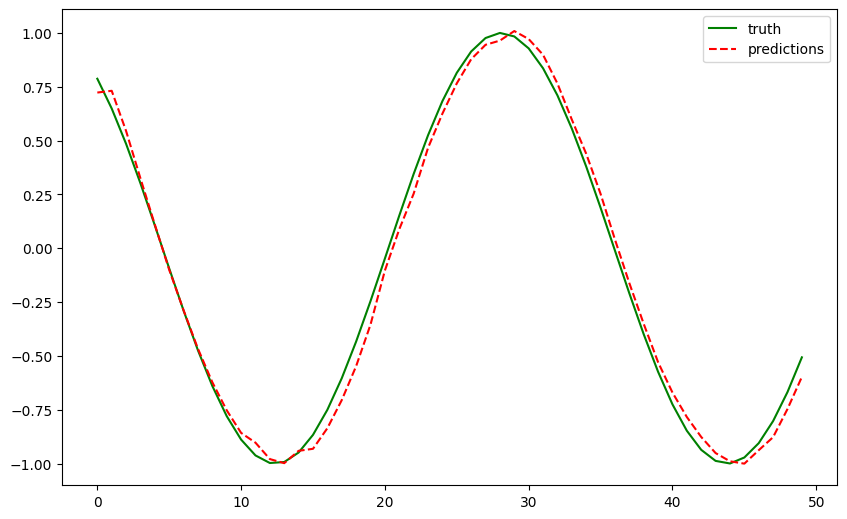

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.18))

ax.plot(
    evaluator_1_step.y_true(dataloader=pdm_1_step.predict_dataloader()),
    "g-",
    label="truth",
)

ax.plot(evaluator_1_step.y(predictions_1_step), "r--", label="predictions")

# ax.plot(evaluator_1_step.y(lobs_1_step_predictions), "b-.", label="naive predictions")

plt.legend()

In [ ]:
trainer_naive_1_step = pl.Trainer(precision=precision)

lobs_forecaster_1_step = LastObservationForecaster(horizon=horizon_1_step)
lobs_1_step_predictions = trainer_naive_1_step.predict(
    model=lobs_forecaster_1_step, datamodule=pdm_1_step
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6.18))

ax.plot(
    evaluator_1_step.y_true(dataloader=pdm_1_step.predict_dataloader()),
    "g-",
    label="truth",
)

ax.plot(evaluator_1_step.y(predictions_1_step), "r--", label="predictions")

ax.plot(evaluator_1_step.y(lobs_1_step_predictions), "b-.", label="naive predictions")

plt.legend()

In [ ]:
evaluator_1_step.metrics(predictions_1_step, pdm_1_step.predict_dataloader())

In [ ]:
evaluator_1_step.metrics(
    [[i.unsqueeze(-1) for i in lobs_1_step_predictions[0]]],
    pdm_1_step.predict_dataloader(),
)